   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 41.6 MB/s eta 0:00:00
請上傳 Ocean current data：CMEMS_YilanBay_20240324_20240328_6hour_depth.nc


Saving CMEMS_YilanBay_20240324_20240328_6hour_depth.nc to CMEMS_YilanBay_20240324_20240328_6hour_depth.nc

Required simulation period:
Start UTC: 2024-03-26 15:00:00
End UTC  : 2024-03-27 03:00:00


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)



12-h estimated spawning center:
Latitude  = 24.417861°N
Longitude = 121.973271°E
Centroid displacement from Station 15 = 28.138 km

Particle stopping summary:
{'active_to_end': 0, 'stopped_by_land': 0, 'stopped_by_domain': 371, 'total_particles': 371}


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


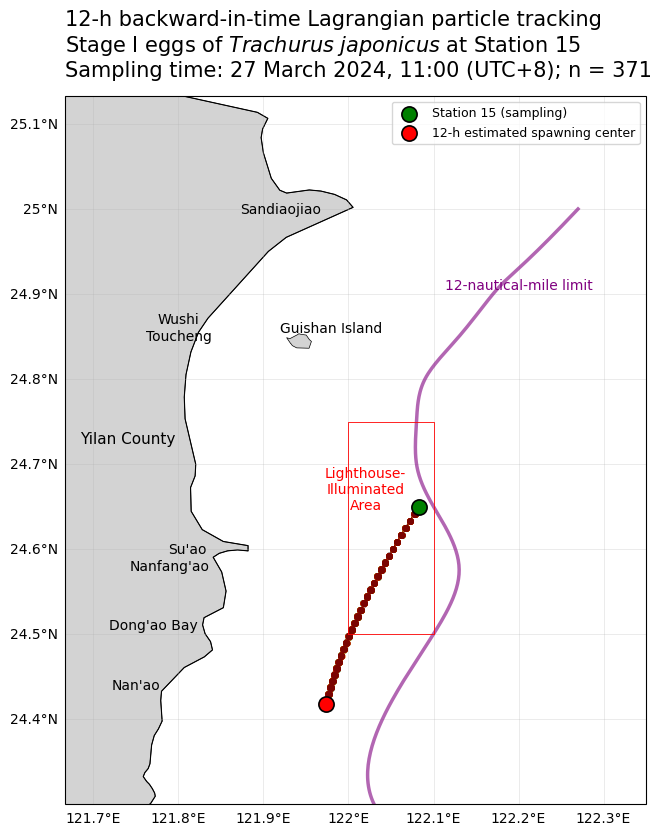


Summary:


,station,species,stage,egg_number,sampling_time_UTC8,sampling_time_UTC,backtracking_duration_h,estimated_spawning_center_lat,estimated_spawning_center_lon,centroid_displacement_km,...,current_file,current_temporal_resolution,current_area,current_time_range_UTC,depth_range_m,time_step_s,displayed_point_interval_min,random_seed,boundary_rule,trajectory_display
0,Station 15,Trachurus japonicus,Stage I,371,2024-03-27 11:00,2024-03-27 03:00,12,24.417861,121.973271,28.137549,...,CMEMS_YilanBay_20240324_20240328_6hour_depth.nc,6-hourly,"121.75-122.65E, 24.35-25.25N",2024-03-24 00:00 to 2024-03-28 00:00,0.49-34.43,300,20.0,20240602,Particles entering land or leaving valid CMEMS...,Faint lines plus sparse particle positions eve...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# Station 15 Trachurus japonicus Stage I eggs
# 12-h backward-in-time Lagrangian particle tracking
# With land mask, LIA box, smoothed 12-nmi line, and sparse trajectory points
# ============================================================

!pip -q install xarray netCDF4 scipy pandas matplotlib cartopy shapely

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.interpolate import RegularGridInterpolator, make_interp_spline
from google.colab import files

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from shapely.geometry import Point
from shapely.ops import unary_union
from shapely.prepared import prep

EXPECTED_FILE = "CMEMS_YilanBay_20240324_20240328_6hour_depth.nc"

print(f"請上傳 Ocean current data：{EXPECTED_FILE}")
uploaded = files.upload()

if EXPECTED_FILE in uploaded:
    nc_file = EXPECTED_FILE
else:
    nc_file = list(uploaded.keys())[0]
    print(f"未偵測到指定檔名，改用上傳檔案：{nc_file}")

ds = xr.open_dataset(nc_file)

species_label = r"$\it{Trachurus\ japonicus}$"

st_lat = 24.65
st_lon = 122.0833
n_particles = 371

# 2024-03-27 11:00 UTC+8 = 2024-03-27 03:00 UTC
sample_time = np.datetime64("2024-03-27T03:00:00")
duration_h = 12
dt_sec = 300
point_stride = 4
random_seed = 20240602
perturb_radius_m = 50

np.random.seed(random_seed)

map_extent = [121.6666, 122.35, 24.3, 25.1333]

depth_min = 0.49
depth_max = 34.43

lia_lon_min = 122.0
lia_lon_max = 122.1
lia_lat_min = 24.5
lia_lat_max = 24.75

limit12_lat_raw = np.array([
    25.00, 24.93, 24.90, 24.85, 24.80, 24.75,
    24.70, 24.65, 24.58, 24.50, 24.40, 24.30
])

limit12_lon_raw = np.array([
    122.27, 122.20, 122.17, 122.13, 122.09, 122.08,
    122.08, 122.10, 122.13, 122.10, 122.04, 122.03
])

t_raw = np.arange(len(limit12_lon_raw))
t_smooth = np.linspace(t_raw.min(), t_raw.max(), 300)

limit12_lon = make_interp_spline(t_raw, limit12_lon_raw, k=3)(t_smooth)
limit12_lat = make_interp_spline(t_raw, limit12_lat_raw, k=3)(t_smooth)

rename_dict = {}
if "lon" in ds.coords:
    rename_dict["lon"] = "longitude"
if "lat" in ds.coords:
    rename_dict["lat"] = "latitude"
if "time_counter" in ds.coords:
    rename_dict["time_counter"] = "time"

if rename_dict:
    ds = ds.rename(rename_dict)

if "uo" not in ds.variables or "vo" not in ds.variables:
    raise ValueError("找不到 uo 或 vo，請確認上傳的是 CMEMS current 檔案。")

ds["time"] = pd.to_datetime(ds["time"].values)

if float(ds["longitude"].max()) > 180:
    ds = ds.assign_coords(longitude=(((ds["longitude"] + 180) % 360) - 180))

ds = ds.sortby("longitude").sortby("latitude")

needed_start = sample_time - np.timedelta64(duration_h, "h")
needed_end = sample_time

print("\nRequired simulation period:")
print("Start UTC:", pd.Timestamp(needed_start))
print("End UTC  :", pd.Timestamp(needed_end))

if pd.Timestamp(ds.time.values[0]) > pd.Timestamp(needed_start):
    raise ValueError("nc 檔案起始時間不足，無法支撐 12 h 回溯。")

if pd.Timestamp(ds.time.values[-1]) < pd.Timestamp(needed_end):
    raise ValueError("nc 檔案結束時間不足，無法支撐 12 h 回溯。")

land_shp = shpreader.natural_earth(
    resolution="10m",
    category="physical",
    name="land"
)

land_union = unary_union(list(shpreader.Reader(land_shp).geometries()))
land_prepared = prep(land_union)

def is_land(lon, lat):
    return land_prepared.contains(Point(float(lon), float(lat)))

def is_land_array(lons, lats):
    return np.array([is_land(lon, lat) for lon, lat in zip(lons, lats)], dtype=bool)

if is_land(st_lon, st_lat):
    raise ValueError("Station 15 被 land mask 判定為陸地，請檢查座標。")

ds_depth = ds.sel(depth=slice(depth_min, depth_max))

u_da = ds_depth["uo"].mean(dim="depth", skipna=True).transpose("time", "latitude", "longitude")
v_da = ds_depth["vo"].mean(dim="depth", skipna=True).transpose("time", "latitude", "longitude")

time_vals = pd.to_datetime(u_da["time"].values)
time_sec = ((time_vals - pd.Timestamp("1970-01-01")) / pd.Timedelta(seconds=1)).astype(float)

lat_vals = u_da["latitude"].values.astype(float)
lon_vals = u_da["longitude"].values.astype(float)

u_interp = RegularGridInterpolator(
    (time_sec, lat_vals, lon_vals),
    u_da.values.astype(float),
    bounds_error=False,
    fill_value=np.nan
)

v_interp = RegularGridInterpolator(
    (time_sec, lat_vals, lon_vals),
    v_da.values.astype(float),
    bounds_error=False,
    fill_value=np.nan
)

def datetime64_to_seconds(t):
    return float((pd.Timestamp(t) - pd.Timestamp("1970-01-01")) / pd.Timedelta(seconds=1))

def get_uv(time_np64, lats, lons):
    pts = np.column_stack([
        np.full(len(lats), datetime64_to_seconds(time_np64), dtype=float),
        np.asarray(lats, dtype=float),
        np.asarray(lons, dtype=float)
    ])
    return u_interp(pts), v_interp(pts)

def initialize_particles(lon0, lat0, n, radius_m=50):
    theta = np.random.uniform(0, 2 * np.pi, n)
    r = radius_m * np.sqrt(np.random.uniform(0, 1, n))

    dx = r * np.cos(theta)
    dy = r * np.sin(theta)

    lons = lon0 + dx / (111320.0 * np.cos(np.deg2rad(lat0)))
    lats = lat0 + dy / 111320.0

    return lons, lats

def advect_backward_with_land_stop(duration_h):
    n_steps = int(duration_h * 3600 / dt_sec)

    lons, lats = initialize_particles(st_lon, st_lat, n_particles, perturb_radius_m)

    traj_lon = np.full((n_steps + 1, n_particles), np.nan)
    traj_lat = np.full((n_steps + 1, n_particles), np.nan)

    traj_lon[0, :] = lons
    traj_lat[0, :] = lats

    active = np.ones(n_particles, dtype=bool)
    last_valid_lon = lons.copy()
    last_valid_lat = lats.copy()

    stopped_by_land = np.zeros(n_particles, dtype=bool)
    stopped_by_domain = np.zeros(n_particles, dtype=bool)

    lon_min = float(ds.longitude.min())
    lon_max = float(ds.longitude.max())
    lat_min = float(ds.latitude.min())
    lat_max = float(ds.latitude.max())

    current_time = sample_time

    for k in range(n_steps):
        dt = -dt_sec

        idx = np.where(active)[0]
        if len(idx) == 0:
            break

        cur_lons = lons[idx]
        cur_lats = lats[idx]

        u1, v1 = get_uv(current_time, cur_lats, cur_lons)
        valid1 = ~(np.isnan(u1) | np.isnan(v1))

        if not np.all(valid1):
            bad_idx = idx[~valid1]
            active[bad_idx] = False
            stopped_by_domain[bad_idx] = True

            idx = idx[valid1]
            cur_lons = cur_lons[valid1]
            cur_lats = cur_lats[valid1]
            u1 = u1[valid1]
            v1 = v1[valid1]

        if len(idx) == 0:
            current_time += np.timedelta64(dt, "s")
            continue

        lon_mid = cur_lons + 0.5 * dt * u1 / (111320.0 * np.cos(np.deg2rad(cur_lats)))
        lat_mid = cur_lats + 0.5 * dt * v1 / 111320.0
        time_mid = current_time + np.timedelta64(int(dt / 2), "s")

        u2, v2 = get_uv(time_mid, lat_mid, lon_mid)
        valid2 = ~(np.isnan(u2) | np.isnan(v2))

        if not np.all(valid2):
            bad_idx = idx[~valid2]
            active[bad_idx] = False
            stopped_by_domain[bad_idx] = True

            idx = idx[valid2]
            cur_lons = cur_lons[valid2]
            cur_lats = cur_lats[valid2]
            lat_mid = lat_mid[valid2]
            u2 = u2[valid2]
            v2 = v2[valid2]

        if len(idx) == 0:
            current_time += np.timedelta64(dt, "s")
            continue

        new_lons = cur_lons + dt * u2 / (111320.0 * np.cos(np.deg2rad(lat_mid)))
        new_lats = cur_lats + dt * v2 / 111320.0

        on_land = is_land_array(new_lons, new_lats)

        inside_domain = (
            (new_lons >= lon_min) &
            (new_lons <= lon_max) &
            (new_lats >= lat_min) &
            (new_lats <= lat_max)
        )

        valid_move = (~on_land) & inside_domain

        if not np.all(valid_move):
            bad_idx = idx[~valid_move]
            active[bad_idx] = False
            stopped_by_land[bad_idx] = on_land[~valid_move]
            stopped_by_domain[bad_idx] = stopped_by_domain[bad_idx] | (~inside_domain[~valid_move])

        good_idx = idx[valid_move]

        lons[good_idx] = new_lons[valid_move]
        lats[good_idx] = new_lats[valid_move]

        last_valid_lon[good_idx] = lons[good_idx]
        last_valid_lat[good_idx] = lats[good_idx]

        traj_lon[k + 1, good_idx] = lons[good_idx]
        traj_lat[k + 1, good_idx] = lats[good_idx]

        current_time += np.timedelta64(dt, "s")

    centroid_lon = float(np.mean(last_valid_lon))
    centroid_lat = float(np.mean(last_valid_lat))

    stop_summary = {
        "active_to_end": int(np.sum(active)),
        "stopped_by_land": int(np.sum(stopped_by_land)),
        "stopped_by_domain": int(np.sum(stopped_by_domain)),
        "total_particles": int(n_particles)
    }

    return traj_lon, traj_lat, centroid_lon, centroid_lat, last_valid_lon, last_valid_lat, stop_summary

traj_lon, traj_lat, cen_lon, cen_lat, last_lon, last_lat, stop_summary = advect_backward_with_land_stop(duration_h)

disp_km = np.sqrt(
    ((cen_lon - st_lon) * 111.32 * np.cos(np.deg2rad(st_lat)))**2 +
    ((cen_lat - st_lat) * 111.32)**2
)

print(f"\n{duration_h}-h estimated spawning center:")
print(f"Latitude  = {cen_lat:.6f}°N")
print(f"Longitude = {cen_lon:.6f}°E")
print(f"Centroid displacement from Station 15 = {disp_km:.3f} km")
print("\nParticle stopping summary:")
print(stop_summary)

place_labels = [
    ("Sandiaojiao", 121.92, 25.00, 10),
    ("Wushi", 121.80, 24.87, 10),
    ("Toucheng", 121.80, 24.85, 10),
    ("Guishan Island", 121.98, 24.86, 10),
    ("Yilan County", 121.74, 24.73, 11),
    ("Su'ao", 121.81, 24.60, 10),
    ("Nanfang'ao", 121.79, 24.58, 10),
    ("Dong'ao Bay", 121.77, 24.51, 10),
    ("Nan'ao", 121.75, 24.44, 10),
]

fig = plt.figure(figsize=(8.2, 9.2))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(map_extent, crs=ccrs.PlateCarree())

ax.add_feature(
    cfeature.LAND,
    facecolor="lightgray",
    edgecolor="black",
    linewidth=0.5,
    zorder=0
)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=1)

gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.35)
gl.top_labels = False
gl.right_labels = False
gl.xlocator = mticker.MultipleLocator(0.1)
gl.ylocator = mticker.MultipleLocator(0.1)
gl.xlabel_style = {"size": 10}
gl.ylabel_style = {"size": 10}

ax.plot(
    limit12_lon,
    limit12_lat,
    color="purple",
    linewidth=2.5,
    alpha=0.60,
    transform=ccrs.PlateCarree(),
    zorder=2
)

ax.text(
    122.20,
    24.91,
    "12-nautical-mile limit",
    fontsize=10,
    color="purple",
    ha="center",
    va="center",
    transform=ccrs.PlateCarree(),
    zorder=10
)

lia_lons = [lia_lon_min, lia_lon_max, lia_lon_max, lia_lon_min, lia_lon_min]
lia_lats = [lia_lat_min, lia_lat_min, lia_lat_max, lia_lat_max, lia_lat_min]

ax.plot(
    lia_lons,
    lia_lats,
    color="red",
    linewidth=0.6,
    transform=ccrs.PlateCarree(),
    zorder=5
)

ax.text(
    122.02,
    24.67,
    "Lighthouse-\nIlluminated\nArea",
    fontsize=10,
    color="red",
    ha="center",
    va="center",
    transform=ccrs.PlateCarree(),
    zorder=10
)

colors = plt.cm.turbo(np.linspace(0, 1, n_particles))

for i in range(n_particles):
    valid = ~np.isnan(traj_lon[:, i]) & ~np.isnan(traj_lat[:, i])

    ax.plot(
        traj_lon[valid, i],
        traj_lat[valid, i],
        color=colors[i],
        linewidth=0.35,
        alpha=0.20,
        transform=ccrs.PlateCarree(),
        zorder=3
    )

    valid_indices = np.where(valid)[0]
    sparse_indices = valid_indices[::point_stride]

    ax.scatter(
        traj_lon[sparse_indices, i],
        traj_lat[sparse_indices, i],
        s=12,
        color=colors[i],
        alpha=0.70,
        transform=ccrs.PlateCarree(),
        zorder=4
    )

ax.scatter(
    st_lon,
    st_lat,
    s=120,
    facecolor="green",
    edgecolor="black",
    linewidth=1.2,
    transform=ccrs.PlateCarree(),
    zorder=8,
    label="Station 15 (sampling)"
)

ax.scatter(
    cen_lon,
    cen_lat,
    s=120,
    facecolor="red",
    edgecolor="black",
    linewidth=1.2,
    transform=ccrs.PlateCarree(),
    zorder=9,
    label="12-h estimated spawning center"
)

for name, lon, lat, fsize in place_labels:
    ax.text(
        lon,
        lat,
        name,
        fontsize=fsize,
        ha="center",
        va="center",
        transform=ccrs.PlateCarree(),
        zorder=10
    )

title = (
    f"12-h backward-in-time Lagrangian particle tracking\n"
    f"Stage I eggs of {species_label} at Station 15\n"
    f"Sampling time: 27 March 2024, 11:00 (UTC+8); n = 371"
)

ax.set_title(title, fontsize=15, loc="left", pad=14)
ax.legend(loc="upper right", fontsize=9, frameon=True)

out_png = "St15_Tjaponicus_backtracking_12h_landmask_LIA_12nmi_sparse_points.png"
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

summary_df = pd.DataFrame([{
    "station": "Station 15",
    "species": "Trachurus japonicus",
    "stage": "Stage I",
    "egg_number": n_particles,
    "sampling_time_UTC8": "2024-03-27 11:00",
    "sampling_time_UTC": "2024-03-27 03:00",
    "backtracking_duration_h": duration_h,
    "estimated_spawning_center_lat": cen_lat,
    "estimated_spawning_center_lon": cen_lon,
    "centroid_displacement_km": disp_km,
    "active_to_end": stop_summary["active_to_end"],
    "stopped_by_land": stop_summary["stopped_by_land"],
    "stopped_by_domain": stop_summary["stopped_by_domain"],
    "current_product": "GLOBAL_ANALYSISFORECAST_PHY_001_024",
    "current_dataset": "cmems_mod_glo_phy-cur_anfc_0.083deg_PT6H-i",
    "current_file": EXPECTED_FILE,
    "current_temporal_resolution": "6-hourly",
    "current_area": "121.75-122.65E, 24.35-25.25N",
    "current_time_range_UTC": "2024-03-24 00:00 to 2024-03-28 00:00",
    "depth_range_m": "0.49-34.43",
    "time_step_s": dt_sec,
    "displayed_point_interval_min": point_stride * dt_sec / 60,
    "random_seed": random_seed,
    "boundary_rule": "Particles entering land or leaving valid CMEMS domain were stopped at their last valid ocean position.",
    "trajectory_display": "Faint lines plus sparse particle positions every 20 minutes."
}])

summary_csv = "St15_Tjaponicus_backtracking_12h_landmask_LIA_12nmi_sparse_points_summary.csv"
summary_df.to_csv(summary_csv, index=False)

print("\nSummary:")
display(summary_df)

files.download(out_png)
files.download(summary_csv)